In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
leish_data=pd.read_csv("/content/drive/MyDrive/Prédiction des cas de leishmaniose dans la province de ouarzazate/Modélisation/leish_data_2010_2022.csv")

In [ ]:
leish_data["Log_transformed"]=np.log(leish_data["Cases"])

In [ ]:
leish_data.head()

,Date,Cases,Log_transformed
0,2010-01-01,71,4.262680
1,2010-02-01,54,3.988984
2,2010-03-01,48,3.871201
3,2010-04-01,20,2.995732
4,2010-05-01,17,2.833213


In [ ]:
import plotly.express as px

In [ ]:
px.line(leish_data,x="Date",y="Log_transformed")

In [ ]:
ts=leish_data.set_index("Date")["Log_transformed"]

##AR

In [ ]:
len(ts.diff().dropna())*0.7

108.5

In [ ]:
train_df=ts.diff().dropna()[:109]
val_df=ts.diff().dropna()[109:]

In [ ]:
len(train_df),len(val_df)

(109, 46)

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
param_grid={"Lags":[10,11,12],
            "Periods" : range(12,25)}

eval=pd.DataFrame(columns=["model","train_RMSE","val_RMSE","train_R2","val_R2"])
for lag in param_grid["Lags"] :
    for period in param_grid["Periods"] :
        model=AutoReg(train_df, lags=lag,seasonal=True, period=period)
        model_fit=model.fit()
        preds=model_fit.predict(start="2019-03-01",end="2022-12-01")
        eval=pd.concat([eval,pd.DataFrame({"model":["L"+str(lag)+"-"+"P"+str(period)],"train_RMSE":[np.sqrt(mean_squared_error(train_df[lag:],model_fit.predict().dropna()))],"val_RMSE":[np.sqrt(mean_squared_error(val_df,preds))],"train_R2":[r2_score(train_df[lag:],model_fit.predict().dropna())],"val_R2":[r2_score(val_df,preds)]})],ignore_index=True,axis=0)

In [ ]:
eval.head()

,model,train_RMSE,val_RMSE,train_R2,val_R2
0,L10-P12,0.238527,0.675454,0.871037,0.266599
1,L10-P13,0.394642,0.656064,0.646983,0.308102
2,L10-P14,0.367433,0.666156,0.693984,0.286652
3,L10-P15,0.320233,0.661098,0.767555,0.297443
4,L10-P16,0.360298,0.671482,0.705754,0.275201


In [ ]:
best_AR_model=eval.iloc[eval["val_R2"].argmax()]

In [ ]:
best_AR_model

model          L11-P18
train_RMSE    0.283768
val_RMSE      0.630216
train_R2      0.817041
val_R2        0.361547
Name: 19, dtype: object

##ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
len(ts)*0.7

109.19999999999999

In [ ]:
train_df=ts[:109]
val_df=ts[109:]

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
param_grid={"p":[7,8,9,10,11,12],
            "d" : [1,2,3],
            "q": [1,2,3,4,5,6,7,8,9,10,11,12]}

eval=pd.DataFrame(columns=["model","train_RMSE","val_RMSE","train_R2","val_R2"])
for p in param_grid["p"] :
    for d in param_grid["d"] :
        for q in param_grid["q"] :
            model=ARIMA(train_df,order=(p,d,q))
            model_fit=model.fit()
            preds=model_fit.predict(start="2019-02-01",end="2022-12-01")
            eval=pd.concat([eval,pd.DataFrame({"model":["P"+str(p)+"-"+"D"+str(d)+"-Q"+str(q)],"train_RMSE":[np.sqrt(mean_squared_error(train_df[d:],model_fit.predict()[d:]))],"val_RMSE":[np.sqrt(mean_squared_error(val_df,preds))],"train_R2": [r2_score(train_df[d:],model_fit.predict()[d:])],"val_R2":[r2_score(val_df,preds)]})],ignore_index=True,axis=0)

In [ ]:
eval.head()

,model,train_RMSE,val_RMSE,train_R2,val_R2
0,P7-D1-Q1,0.416577,0.884500,0.875500,0.337626
1,P7-D1-Q2,0.400961,1.022958,0.884659,0.114021
2,P7-D1-Q3,0.379222,1.080290,0.896827,0.011928
3,P7-D1-Q4,0.380906,0.989559,0.895909,0.170929
4,P7-D1-Q5,0.367771,0.974458,0.902964,0.196040


In [ ]:
best_ARIMA_model=eval.iloc[eval["val_RMSE"].argmin()]
best_ARIMA_model

model         P9-D3-Q8
train_RMSE    0.386731
val_RMSE      0.738921
train_R2      0.892641
val_R2        0.537721
Name: 103, dtype: object

In [ ]:
best_AR_model

model          L11-P18
train_RMSE    0.283768
val_RMSE      0.630216
train_R2      0.817041
val_R2        0.361547
Name: 19, dtype: object

##SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
len(ts)*0.6

93.6

In [ ]:
train_df=ts[:93]
val_df=ts[93:]

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#param_grid={"p":range(8, 12),"d": [2],"q":range(8, 12),"D":range(0, 2),"Q":range(0, 2),"S":[24]}
param_grid={"p":[9],"d": [2],"q":[8],"D":[1],"Q":[1],"S":range(12,25)}
eval=pd.DataFrame(columns=["model","train_RMSE","val_RMSE","train_R2","val_R2"])
for p in param_grid["p"] :
    for d in param_grid["d"] :
       for q in param_grid["q"] :
              for D in param_grid["D"] :
                  for Q in param_grid["Q"] :
                      for S in param_grid["S"] :
                          model=SARIMAX(train_df,order=(p,d,q),seasonal_order=(0,D,Q,S))
                          model_fit=model.fit()
                          preds=model_fit.forecast(steps=len(val_df))
                          train_preds=model_fit.get_prediction(start=0,end=len(train_df)-1).predicted_mean
                          eval=pd.concat([eval,pd.DataFrame({"model":[f"SARIMA({str(p)},{str(d)},{str(q)})(0,{str(D)},{str(Q)})_{str(S)}"],"train_RMSE":[np.sqrt(mean_squared_error(train_df[d:],train_preds[d:]))],"val_RMSE":[np.sqrt(mean_squared_error(val_df,preds))],"train_R2":[r2_score(train_df[d:],train_preds[d:])],"val_R2":[r2_score(val_df,preds)]})],ignore_index=True,axis=0)

In [ ]:
eval.sort_values(by="val_R2",ascending=False).head(20)

,model,train_RMSE,val_RMSE,train_R2,val_R2
12,"SARIMA(9,2,8)(0,1,1)_24",0.440767,0.784723,0.841886,0.516533
4,"SARIMA(9,2,8)(0,1,1)_16",0.441940,0.913866,0.841044,0.344309
3,"SARIMA(9,2,8)(0,1,1)_15",0.476747,0.938802,0.815019,0.308038
7,"SARIMA(9,2,8)(0,1,1)_19",0.521654,1.064016,0.778529,0.111146
0,"SARIMA(9,2,8)(0,1,1)_12",0.318193,1.300491,0.917599,-0.327850
6,"SARIMA(9,2,8)(0,1,1)_18",0.468394,1.500246,0.821444,-0.767091
10,"SARIMA(9,2,8)(0,1,1)_22",0.540947,1.622870,0.761844,-1.067767
1,"SARIMA(9,2,8)(0,1,1)_13",0.485650,1.790131,0.808045,-1.515958
11,"SARIMA(9,2,8)(0,1,1)_23",0.426496,1.948148,0.851959,-1.979737
9,"SARIMA(9,2,8)(0,1,1)_21",0.428250,2.154021,0.850739,-2.642789


In [ ]:
predictions_sarima=pd.concat([np.exp(train_preds),np.exp(preds)]).to_frame().reset_index()

In [ ]:
predictions_sarima

,index,predicted_mean
0,2010-01-01,1.000000
1,2010-02-01,1217.392332
2,2010-03-01,41.070429
3,2010-04-01,42.666666
4,2010-05-01,8.333334
...,...,...
151,2022-08-01,5.592488
152,2022-09-01,9.803289
153,2022-10-01,21.224429
154,2022-11-01,36.986209


In [ ]:
predictions_sarima["Cases"]=np.exp(ts).values

In [ ]:
predictions_sarima[96:]

,index,predicted_mean,Cases
96,2018-01-01,78.572725,131.0
97,2018-02-01,60.835179,146.0
98,2018-03-01,54.343868,137.0
99,2018-04-01,22.571029,30.0
100,2018-05-01,18.880014,44.0
101,2018-06-01,10.332741,26.0
102,2018-07-01,4.747871,7.0
103,2018-08-01,4.846428,2.0
104,2018-09-01,8.208410,11.0
105,2018-10-01,17.858526,58.0


In [ ]:
import plotly.express as px

In [ ]:
px.line(predictions_sarima[96:],x="index",y=["predicted_mean","Cases"],title="Les prédictions du modéle SARIMA sur la période de 2018 à 2022")

##Polynomial model

In [ ]:
import pandas as pd

In [ ]:
#creating the data
df=pd.read_csv("/content/drive/MyDrive/Climat 2001-2018/full_leish_data_2010-2022.csv")

In [ ]:
df.head()

,Annee,Mois,RH2M,TMP_MIN,TMP_MAX,WS2M,WS10M,WD10M,WD2M,UVA,UVB,CLOUD_AMT,SOIL_M,SOIL_W,SOIL_RW,PRECT_TOTAL,SURFACE_P,SH2M,Cases,Date
0,2010,1,58.067647,-10.09,25.55,2.966471,4.247059,311.408235,311.491765,8.597647,0.148824,36.217647,0.527647,0.522941,0.534118,40.324706,83.640588,3.928235,71,2010-01-01
1,2010,2,67.925294,-5.69,26.46,3.704706,5.248235,274.142353,273.551765,9.837059,0.193529,54.170588,0.591765,0.614706,0.604706,83.442941,83.284706,5.432353,54,2010-02-01
2,2010,3,55.660000,-2.11,29.61,3.304118,4.689412,289.415294,288.811765,13.687647,0.314118,42.922941,0.602941,0.616471,0.621765,29.156471,83.697059,4.890000,48,2010-03-01
3,2010,4,49.796471,0.37,32.36,2.674118,3.782353,256.629412,250.105882,16.078824,0.385294,47.584706,0.518824,0.485294,0.527059,1.240588,83.464118,5.765882,20,2010-04-01
4,2010,5,41.630000,1.15,34.27,3.589412,4.928235,316.550000,313.687647,18.395882,0.453529,32.672353,0.462941,0.368824,0.466471,0.310000,83.564118,4.973529,17,2010-05-01


In [ ]:
X=df.drop(["Annee","Mois","Cases"],axis=1).set_index("Date")
y=df[["Date","Cases"]].set_index("Date")["Cases"]

In [ ]:
X.head(10)

,RH2M,TMP_MIN,TMP_MAX,WS2M,WS10M,WD10M,WD2M,UVA,UVB,CLOUD_AMT,SOIL_M,SOIL_W,SOIL_RW,PRECT_TOTAL,SURFACE_P,SH2M
Date,,,,,,,,,,,,,,,,
2010-01-01,58.067647,-10.09,25.55,2.966471,4.247059,311.408235,311.491765,8.597647,0.148824,36.217647,0.527647,0.522941,0.534118,40.324706,83.640588,3.928235
2010-02-01,67.925294,-5.69,26.46,3.704706,5.248235,274.142353,273.551765,9.837059,0.193529,54.170588,0.591765,0.614706,0.604706,83.442941,83.284706,5.432353
2010-03-01,55.660000,-2.11,29.61,3.304118,4.689412,289.415294,288.811765,13.687647,0.314118,42.922941,0.602941,0.616471,0.621765,29.156471,83.697059,4.890000
2010-04-01,49.796471,0.37,32.36,2.674118,3.782353,256.629412,250.105882,16.078824,0.385294,47.584706,0.518824,0.485294,0.527059,1.240588,83.464118,5.765882
2010-05-01,41.630000,1.15,34.27,3.589412,4.928235,316.550000,313.687647,18.395882,0.453529,32.672353,0.462941,0.368824,0.466471,0.310000,83.564118,4.973529
2010-06-01,36.697647,4.94,39.90,3.347647,4.491765,337.824118,335.041765,20.702353,0.528235,14.901176,0.429412,0.192353,0.427059,0.000000,83.620588,5.753529
2010-07-01,25.254118,12.23,41.69,2.905294,3.948824,185.837647,189.037059,17.658235,0.468824,43.257059,0.426471,0.175882,0.422353,1.550588,83.972941,6.157647
2010-08-01,29.615882,7.79,41.26,2.570588,3.495294,199.162353,202.051765,16.436471,0.435294,41.831765,0.431176,0.255882,0.430000,15.510000,84.020000,6.671765
2010-09-01,40.526471,7.44,38.48,2.602941,3.535294,241.623529,239.259412,13.856471,0.353529,48.547647,0.431176,0.254118,0.429412,7.755882,83.905294,7.432353


In [ ]:
y.head()

Date
2010-01-01    71
2010-02-01    54
2010-03-01    48
2010-04-01    20
2010-05-01    17
Name: Cases, dtype: int64

In [ ]:
RH2M=X["RH2M"].shift(6)
TMIN=X["TMP_MIN"].shift(6)
TMAX=X["TMP_MAX"].shift(12)
WS=X["WS2M"].shift(2)
WD=X["WD2M"].shift(5)
UVB=X["UVB"].shift(1)
CLD=X["CLOUD_AMT"].shift(12)
SW=X["SOIL_W"].shift(6)
PRT=X["PRECT_TOTAL"]
SP=X["SURFACE_P"].shift(9)

In [ ]:
X_new=pd.DataFrame(columns=["RH2M_L6","TMIN_L6","TMAX_L12","WS2M_L2","WD2M_L5","UVB_L1","CLOUD_AMT_L12","SOIL_W_L6","PRECT_TOTAL","SURFACE_P_L9"],index=X.index)

In [ ]:
X_new["Cases_L1"]=y.shift(1)
X_new["Cases_L2"]=y.shift(2)
X_new["Cases_L3"]=y.shift(3)
X_new["Cases_L4"]=y.shift(4)
X_new["Cases_L5"]=y.shift(5)
X_new["Cases_L6"]=y.shift(6)
X_new["Cases_L7"]=y.shift(7)
X_new["Cases_L8"]=y.shift(8)
X_new["Cases_L9"]=y.shift(9)
X_new["Cases_L10"]=y.shift(10)
X_new["Cases_L11"]=y.shift(11)
X_new["Cases_L12"]=y.shift(12)
X_new["RH2M_L6"]=RH2M
X_new["TMIN_L6"]=TMIN
X_new["TMAX_L12"]=TMAX
X_new["WS2M_L2"]=WS
X_new["WD2M_L5"]=WD
X_new["UVB_L1"]=UVB
X_new["CLOUD_AMT_L12"]=CLD
X_new["SOIL_W_L6"]=SW
X_new["PRECT_TOTAL"]=PRT
X_new["SURFACE_P_L9"]=SP

In [ ]:
X_new.dropna(inplace=True)

In [ ]:
y_new=y[12:]

In [ ]:
X_new.head()

,RH2M_L6,TMIN_L6,TMAX_L12,WS2M_L2,WD2M_L5,UVB_L1,CLOUD_AMT_L12,SOIL_W_L6,PRECT_TOTAL,SURFACE_P_L9,...,Cases_L3,Cases_L4,Cases_L5,Cases_L6,Cases_L7,Cases_L8,Cases_L9,Cases_L10,Cases_L11,Cases_L12
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-01,25.254118,12.23,25.55,2.609412,202.051765,0.133529,36.217647,0.175882,19.234118,83.464118,...,16.0,7.0,4.0,4.0,10.0,17.0,20.0,48.0,54.0,71.0
2011-02-01,29.615882,7.79,26.46,2.932353,239.259412,0.153529,54.170588,0.255882,5.894118,83.564118,...,27.0,16.0,7.0,4.0,4.0,10.0,17.0,20.0,48.0,54.0
2011-03-01,40.526471,7.44,29.61,2.084706,294.697647,0.223529,42.922941,0.254118,71.034706,83.620588,...,57.0,27.0,16.0,7.0,4.0,4.0,10.0,17.0,20.0,48.0
2011-04-01,53.041176,2.05,32.36,2.438235,289.747647,0.294118,47.584706,0.345882,41.257647,83.972941,...,63.0,57.0,27.0,16.0,7.0,4.0,4.0,10.0,17.0,20.0
2011-05-01,51.827647,-0.14,34.27,2.614118,232.178235,0.390588,32.672353,0.331765,60.177059,84.020000,...,48.0,63.0,57.0,27.0,16.0,7.0,4.0,4.0,10.0,17.0


In [ ]:
y_new.head()

Date
2011-01-01    63
2011-02-01    48
2011-03-01    42
2011-04-01    17
2011-05-01    15
Name: Cases, dtype: int64

In [ ]:
X_nouv=pd.read_csv("/content/drive/MyDrive/Climat 2001-2018/X_new.csv").set_index("Date").drop("SH2M",axis=1)

In [ ]:
len(X_nouv)*0.7

100.8

In [ ]:
X_train,y_train=X_nouv[:101],y_new[:101]
X_val,y_val=X_nouv[101:],y_new[101:]
#X_test,y_test=X_new[86+29:],y_new[86+29:]

In [ ]:
len(X_train),len(X_val)#,len(X_test)

(101, 43)

In [ ]:
#modeling
from sklearn.linear_model import Ridge
alpha=0.0002
best_score=0.0
X_t=pd.DataFrame(index=X_train.index)
X_v=pd.DataFrame(index=X_val.index)
#X_ts=pd.DataFrame(index=X_test.index)
for variable in X_train.columns :
    for i in range(1,5) :
        X_t[f"{variable}^{i}"]=(X_train[variable]**i).values
        model=Ridge(alpha)
        model.fit(X_t,y_train)
        X_v[f"{variable}^{i}"]=(X_val[variable]**i).values
        #X_ts[f"{variable}^{i}"]=(X_test[variable]**i).values
        score=model.score(X_v,y_val)
        if score>=best_score :
           best_score=score
           continue
        else :
           X_t.drop(f"{variable}^{i}",axis=1,inplace=True)
           X_v.drop(f"{variable}^{i}",axis=1,inplace=True)
           #X_ts.drop(f"{variable}^{i}",axis=1,inplace=True)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.50273e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=4.87451e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.02961e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.44656e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarnin

In [ ]:
X_t.head()

,RH2M_L6^1,RH2M_L6^2,TMIN_L6^1,TMIN_L6^2,TMAX_L12^1,TMAX_L12^2,WS2M_L2^4,CLOUD_AMT_L12^1,SURFACE_P_L9^1,Cases_L1^1,...,Cases_L2^2,Cases_L3^1,Cases_L3^3,Cases_L4^3,Cases_L5^1,Cases_L6^1,Cases_L6^2,Cases_L10^1,Cases_L12^1,Cases_L12^2
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-01,25.254118,637.770458,12.23,149.5729,25.55,652.8025,46.362886,36.217647,83.464118,57.0,...,729.0,16.0,4096.0,343.0,4.0,4.0,16.0,48.0,71.0,5041.0
2011-02-01,29.615882,877.100488,7.79,60.6841,26.46,700.1316,73.937535,54.170588,83.564118,63.0,...,3249.0,27.0,19683.0,4096.0,7.0,4.0,16.0,20.0,54.0,2916.0
2011-03-01,40.526471,1642.394818,7.44,55.3536,29.61,876.7521,18.887704,42.922941,83.620588,48.0,...,3969.0,57.0,185193.0,19683.0,16.0,7.0,49.0,17.0,48.0,2304.0
2011-04-01,53.041176,2813.366401,2.05,4.2025,32.36,1047.1696,35.342922,47.584706,83.972941,42.0,...,2304.0,63.0,250047.0,185193.0,27.0,16.0,256.0,10.0,20.0,400.0
2011-05-01,51.827647,2686.105000,-0.14,0.0196,34.27,1174.4329,46.698240,32.672353,84.020000,17.0,...,1764.0,48.0,110592.0,250047.0,57.0,27.0,729.0,4.0,17.0,289.0


In [ ]:
import numpy as np

In [ ]:
best_score=0.0
best_alpha=0
best_solver=""
for alpha in np.logspace(-7, 5, 100000) :
    for solver in ["auto", "svd", "cholesky", "lsqr", "sparse_cg"] :
        model=Ridge(alpha=alpha,solver=solver)
        model.fit(X_t,y_train)
        score=model.score(X_v,y_val)
        if score>best_score :
          best_score=score
          best_alpha=alpha
          best_solver=solver

In [ ]:
best_score

0.795865780985068

In [ ]:
model=Ridge(alpha=best_alpha,solver=best_solver)
model.fit(X_t,y_train)
model.score(X_t,y_train)

0.8591446438883368

In [ ]:
coefs=pd.DataFrame({"Variables" : X_t.columns,"Coefficients" : list(model.coef_)})


In [ ]:
coefs=pd.concat([coefs,pd.DataFrame({"Variables" : ["Intercept"],"Coefficients" :[model.intercept_]})],ignore_index=True)

In [ ]:
coefs

,Variables,Coefficients
0,RH2M_L6^1,-3.043343
1,RH2M_L6^2,0.027929
2,TMIN_L6^1,-1.034063
3,TMIN_L6^2,-0.010751
4,TMAX_L12^1,-0.270217
5,TMAX_L12^2,-0.000947
6,WS2M_L2^4,0.067443
7,CLOUD_AMT_L12^1,-0.042162
8,SURFACE_P_L9^1,2.805422
9,Cases_L1^1,0.591873


In [ ]:
coefs[coefs["Variables"].str.endswith("^1")]

,Variables,Coefficients
0,RH2M_L6^1,-3.043343
2,TMIN_L6^1,-1.034063
4,TMAX_L12^1,-0.270217
7,CLOUD_AMT_L12^1,-0.042162
8,SURFACE_P_L9^1,2.805422
9,Cases_L1^1,0.591873
11,Cases_L2^1,0.131071
13,Cases_L3^1,-0.127048
16,Cases_L5^1,0.037491
17,Cases_L6^1,0.037949


In [ ]:
train_preds=pd.Series(model.predict(X_t),index=X_t.index)
val_preds=pd.Series(model.predict(X_v),index=X_v.index)
preds_poly=pd.concat([train_preds,val_preds],axis=0).reset_index()
preds_poly["Cases"]=y[12:].values

In [ ]:
preds_poly.columns=["Date","y_pred","Cases"]

In [ ]:
px.line(preds_poly[84:],x="Date",y=["y_pred","Cases"],title="Les prédictions du modéle polynomiale sur la période de 2018 à 2022 ")

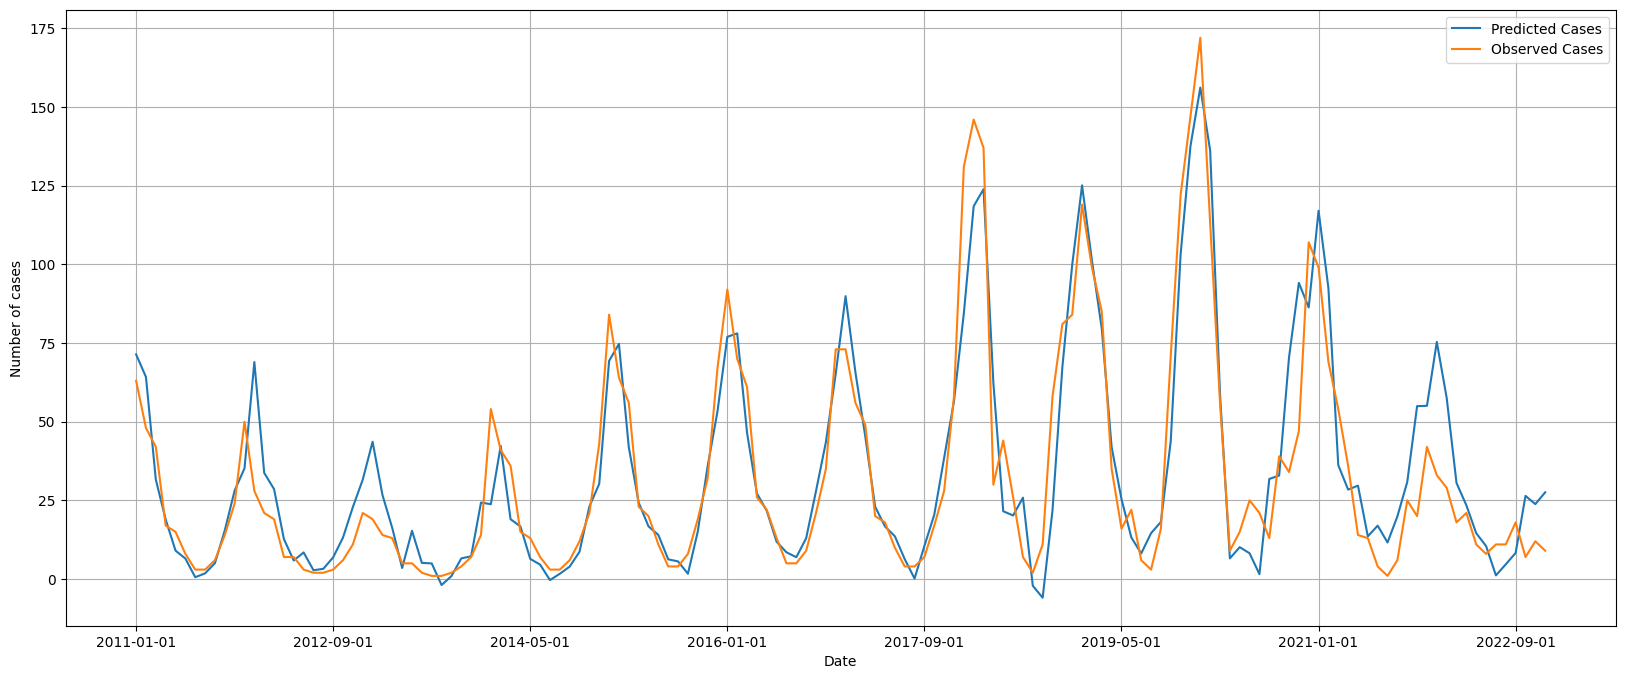

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(preds_poly["Date"],preds_poly["y_pred"],label="Predicted Cases")
plt.plot(preds_poly["Date"],preds_poly["Cases"],label="Observed Cases")
plt.xlabel("Date")
plt.ylabel("Number of cases")
plt.legend()
plt.xticks(ticks=["2011-01-01","2012-09-01","2014-05-01","2016-01-01","2017-09-01","2019-05-01","2021-01-01","2022-09-01"])
plt.grid(True)

##Support Vector Machine

In [ ]:
from sklearn.svm import SVR

In [ ]:
best_score=0.0
X_sv_t=pd.DataFrame(index=X_train.index)
X_sv_v=pd.DataFrame(index=X_val.index)
#X_sv_ts=pd.DataFrame(index=X_test.index)
for variable in X_train.columns :
        X_sv_t[variable]=X_train[variable].values
        model=SVR(C=500)
        model.fit(X_sv_t,y_train)
        X_sv_v[variable]=X_val[variable].values
        #X_sv_ts[variable]=X_test[variable].values
        score=model.score(X_sv_v,y_val)
        if score>=best_score :
           best_score=score
           continue
        else :
           X_sv_t.drop(variable,axis=1,inplace=True)
           X_sv_v.drop(variable,axis=1,inplace=True)
           #X_sv_ts.drop(variable,axis=1,inplace=True)

In [ ]:
X_sv_t.head()

,RH2M_L6,TMIN_L6,TMAX_L12,WS2M_L2,UVB_L1,SOIL_W_L6,SURFACE_P_L9,Cases_L1,Cases_L2,Cases_L5,Cases_L6
Date,,,,,,,,,,,
2011-01-01,25.254118,12.23,25.55,2.609412,0.133529,0.175882,83.464118,57.0,27.0,4.0,4.0
2011-02-01,29.615882,7.79,26.46,2.932353,0.153529,0.255882,83.564118,63.0,57.0,7.0,4.0
2011-03-01,40.526471,7.44,29.61,2.084706,0.223529,0.254118,83.620588,48.0,63.0,16.0,7.0
2011-04-01,53.041176,2.05,32.36,2.438235,0.294118,0.345882,83.972941,42.0,48.0,27.0,16.0
2011-05-01,51.827647,-0.14,34.27,2.614118,0.390588,0.331765,84.020000,17.0,42.0,57.0,27.0


In [ ]:
X_sv_t.columns

In [ ]:
model=SVR(C=700)
model.fit(X_sv_t,y_train)
model.score(X_sv_v,y_val)

0.8355447556065405

In [ ]:
model.score(X_sv_t,y_train)

0.8714754419414295

In [ ]:
train_preds=pd.Series(model.predict(X_sv_t),index=X_sv_t.index)
val_preds=pd.Series(model.predict(X_sv_v),index=X_sv_v.index)
preds_svr=pd.concat([train_preds,val_preds],axis=0).reset_index()
preds_svr["Cases"]=y[12:].values

In [ ]:
preds_svr.columns=["Date","y_pred","Cases"]

In [ ]:
import plotly.express as px

In [ ]:
px.line(preds_svr[84:],x="Date",y=["y_pred","Cases"],title="Les prédictions du modéle SVR sur la période de 2018 à 2022")

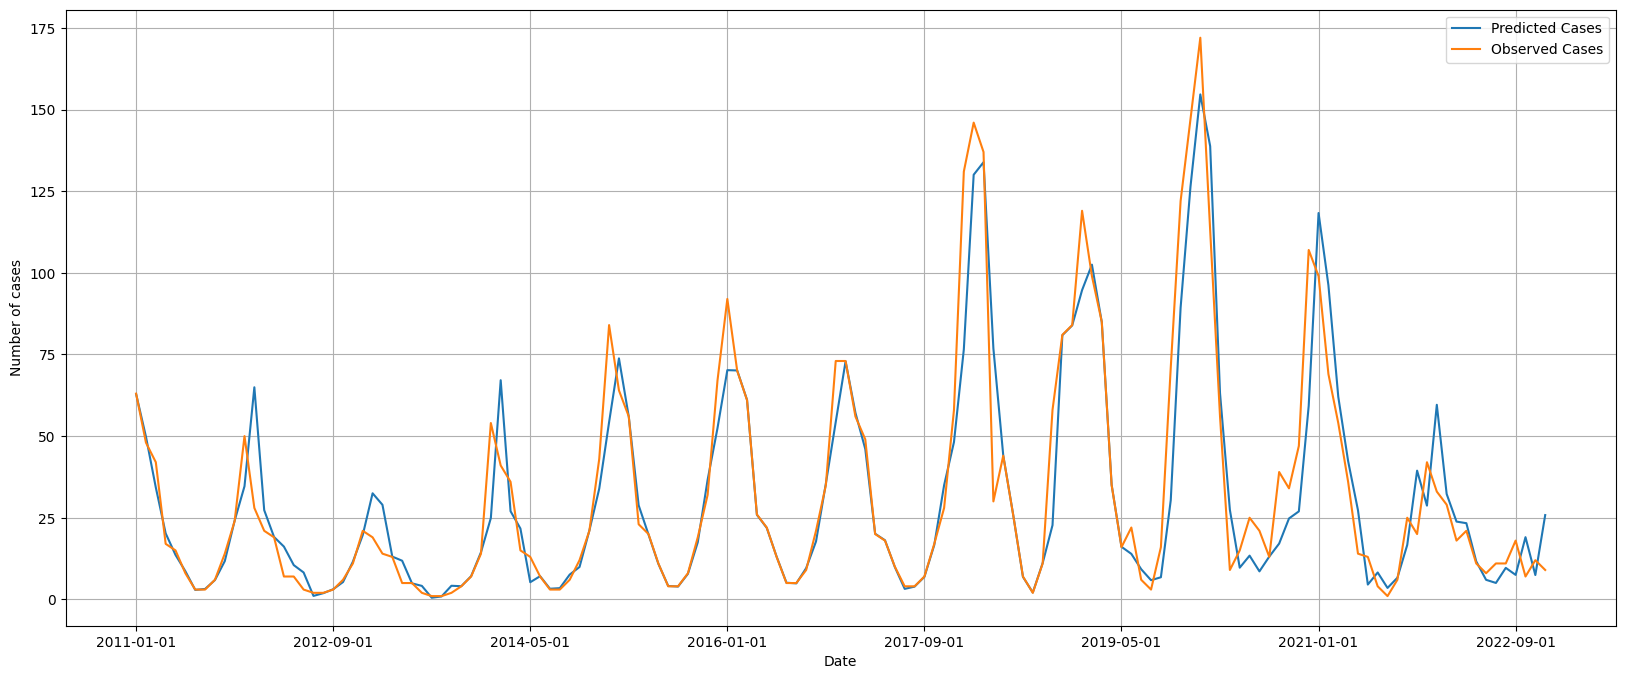

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(preds_svr["Date"],preds_svr["y_pred"],label="Predicted Cases")
plt.plot(preds_svr["Date"],preds_svr["Cases"],label="Observed Cases")
plt.xlabel("Date")
plt.ylabel("Number of cases")
plt.legend()
plt.xticks(ticks=["2011-01-01","2012-09-01","2014-05-01","2016-01-01","2017-09-01","2019-05-01","2021-01-01","2022-09-01"])
plt.grid(True)